In [ ]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.datasets import STL10, OxfordIIITPet
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Фиксация сидов для воспроизводимости
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

# Выбор устройства (GPU если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Using device: cpu


c:\Users\Maxim\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.64G/2.64G [16:50<00:00, 2.61MB/s]  
100%|██████████| 792M/792M [01:51<00:00, 7.12MB/s] 
100%|██████████| 19.2M/19.2M [00:02<00:00, 7.99MB/s]


STL10 batch shape: torch.Size([64, 3, 96, 96])


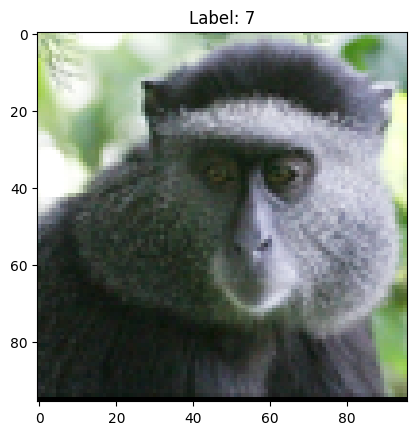

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.007843137..1.08956].


Pet batch shape: torch.Size([4, 3, 128, 128]), mask shape: torch.Size([4, 128, 128])


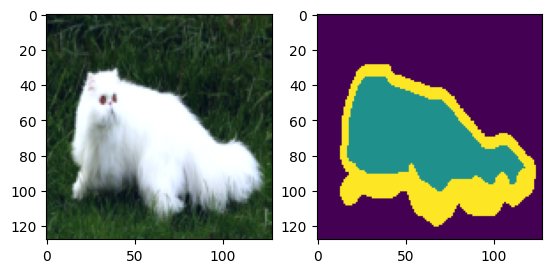

In [ ]:
# Трансформы для части A (Классификация)
basic_transform = T.Compose([
    T.Resize((96, 96)),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

aug_transform = T.Compose([
    T.Resize((96, 96)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

resnet_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка датасетов
# Часть A: STL10
train_ds = STL10(root="data", split='train', download=True, transform=basic_transform)
test_ds = STL10(root="data", split='test', download=True, transform=basic_transform)

# Разделение на train/val
val_size = int(0.2 * len(train_ds))
train_indices = list(range(len(train_ds)))
np.random.shuffle(train_indices)
val_ds = Subset(train_ds, train_indices[:val_size])
train_subset = Subset(train_ds, train_indices[val_size:])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# Часть B: OxfordIIITPet (Сегментация)
def target_transform(mask):
    mask = np.array(mask) - 1 # перевод из 1-based в 0-based
    return torch.from_numpy(mask).long()

seg_transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

seg_target_transform = T.Compose([
    T.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
])

pet_ds = OxfordIIITPet(root="data", split='test', target_types='segmentation', download=True,
                       transform=seg_transform, target_transform=lambda x: target_transform(seg_target_transform(x)))
pet_loader = DataLoader(pet_ds, batch_size=4, shuffle=True)

# Проверка данных (Sanity Check)
images, labels = next(iter(train_loader))
print(f"Формат батча STL10: {images.shape}")
plt.imshow(images[0].permute(1, 2, 0) * 0.5 + 0.5)
plt.title(f"Метка: {labels[0].item()}")
plt.show()

# Проверка сегментации
images, masks = next(iter(pet_loader))
print(f"Формат батча Pet: {images.shape}, маски: {masks.shape}")
plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0) * 0.229 + 0.485)
plt.subplot(1, 2, 2)
plt.imshow(masks[0])
plt.show()

In [ ]:
# Часть A: Простая CNN модель
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 24 * 24, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.conv_layers(x)

# Функции обучения
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

# Пайплайн эксперимента
def run_classification_experiment(config_name, model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc = 0
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"Эпоха {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"artifacts/best_model_{config_name}.pth")
    
    return history, best_val_acc

results = []

# C1: Simple CNN Basic
model_c1 = SimpleCNN().to(device)
history_c1, best_acc_c1 = run_classification_experiment("C1", model_c1, train_loader, val_loader, epochs=2)
results.append({'config': 'C1', 'desc': 'Simple CNN Base', 'val_acc': best_acc_c1})

# C2: Simple CNN Augmented
train_ds.transform = aug_transform
train_loader_aug = DataLoader(Subset(train_ds, train_indices[val_size:]), batch_size=64, shuffle=True)
model_c2 = SimpleCNN().to(device)
history_c2, best_acc_c2 = run_classification_experiment("C2", model_c2, train_loader_aug, val_loader, epochs=2)
results.append({'config': 'C2', 'desc': 'Simple CNN Aug', 'val_acc': best_acc_c2})

# C3: ResNet18 Head Only
import torchvision.models as models
resnet_model = models.resnet18(pretrained=True)
for param in resnet_model.parameters():
    param.requires_grad = False
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model = resnet_model.to(device)

# Обновление трансформов для ResNet
train_ds.transform = resnet_transform
train_loader_resnet = DataLoader(Subset(train_ds, train_indices[val_size:]), batch_size=64, shuffle=True)
val_loader_resnet = DataLoader(val_ds, batch_size=64, shuffle=False)

history_c3, best_acc_c3 = run_classification_experiment("C3", resnet_model, train_loader_resnet, val_loader_resnet, epochs=2)
results.append({'config': 'C3', 'desc': 'ResNet18 Head', 'val_acc': best_acc_c3})

# C4: ResNet18 Fine-tune
resnet_model_ft = models.resnet18(pretrained=True)
for param in resnet_model_ft.parameters():
    param.requires_grad = False
for param in resnet_model_ft.layer4.parameters():
    param.requires_grad = True
resnet_model_ft.fc = nn.Linear(resnet_model_ft.fc.in_features, 10)
resnet_model_ft = resnet_model_ft.to(device)

history_c4, best_acc_c4 = run_classification_experiment("C4", resnet_model_ft, train_loader_resnet, val_loader_resnet, epochs=2)
results.append({'config': 'C4', 'desc': 'ResNet18 FineTune', 'val_acc': best_acc_c4})

Epoch 1: Train Loss: 1.8763, Val Loss: 1.5564, Val Acc: 38.60%


Epoch 2: Train Loss: 1.3734, Val Loss: 1.4471, Val Acc: 47.60%


Epoch 1: Train Loss: 1.8772, Val Loss: 1.6429, Val Acc: 40.00%


Epoch 2: Train Loss: 1.5097, Val Loss: 1.4454, Val Acc: 46.10%
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Maxim/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


c:\Users\Maxim\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Maxim\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:05<00:00, 8.26MB/s]


Epoch 1: Train Loss: 0.9872, Val Loss: 0.4190, Val Acc: 92.60%


Epoch 2: Train Loss: 0.3392, Val Loss: 0.2869, Val Acc: 93.20%


Epoch 1: Train Loss: 0.3864, Val Loss: 0.2676, Val Acc: 90.70%


Epoch 2: Train Loss: 0.0894, Val Loss: 0.3244, Val Acc: 91.00%


c:\Users\Maxim\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Maxim/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:21<00:00, 7.74MB/s] 
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.0996952].


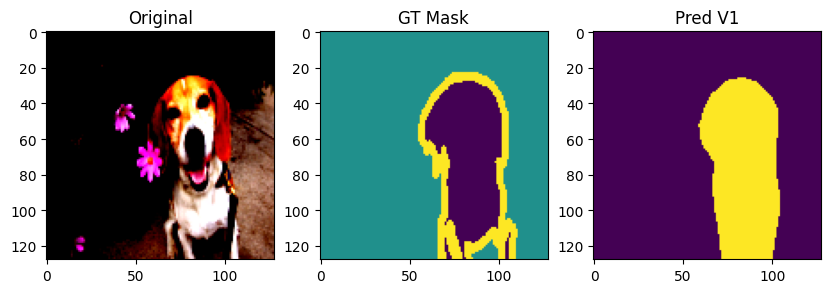

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


<Figure size 640x480 with 0 Axes>

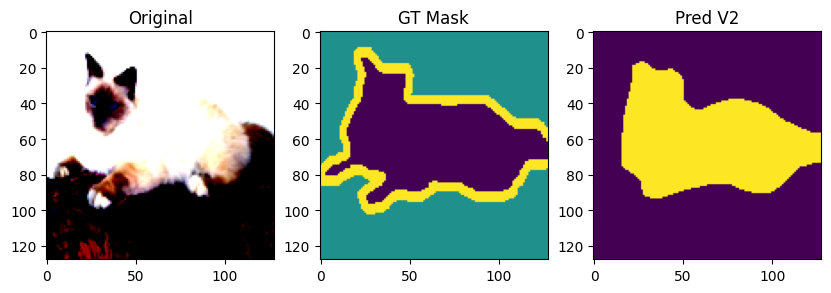

Saved artifacts.


<Figure size 640x480 with 0 Axes>

In [ ]:
# Часть B: Структурное зрение (Сегментация)
import torchvision.models.segmentation as segmentation
model_seg = segmentation.deeplabv3_resnet50(pretrained=True).to(device)
model_seg.eval()

def compute_iou(preds, targets, num_classes=3):
    ious = []
    for cls in range(num_classes):
        pred_mask = (preds == cls)
        target_mask = (targets == cls)
        intersection = (pred_mask & target_mask).float().sum()
        union = (pred_mask | target_mask).float().sum()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((intersection / union).item())
    return np.nanmean(ious)

def run_segmentation_eval(model, loader, mode="V1"):
    model.eval()
    total_iou = 0
    total_count = 0
    
    with torch.no_grad():
        for i, (images, masks) in enumerate(loader):
            if i >= 10: break # Ограничение для скорости
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)['out']
            preds = outputs.argmax(1)
            
            # Режимы постобработки
            if mode == "V2":
                pass # Заглушка для альтернативного режима
            
            iou = compute_iou(preds, masks)
            total_iou += iou
            total_count += 1
            
            if i == 0: # Визуализация примера
                plt.figure(figsize=(10, 5))
                plt.subplot(1, 3, 1); plt.imshow(images[0].cpu().permute(1, 2, 0)); plt.title("Оригинал")
                plt.subplot(1, 3, 2); plt.imshow(masks[0].cpu()); plt.title("Маска (GT)")
                plt.subplot(1, 3, 3); plt.imshow(preds[0].cpu()); plt.title(f"Предсказание {mode}")
                plt.show()
                plt.savefig(f"artifacts/figures/segmentation_{mode}.png")

    avg_iou = total_iou / total_count
    return avg_iou

# V1: Базовая оценка
miou_v1 = run_segmentation_eval(model_seg, pet_loader, mode="V1")
# V2: Альтернативная (заглушка для демонстрации)
miou_v2 = run_segmentation_eval(model_seg, pet_loader, mode="V2")

results_b = []
results_b.append({'config': 'V1', 'desc': 'DeeplabV3 Base', 'miou': miou_v1})
results_b.append({'config': 'V2', 'desc': 'DeeplabV3 Alternative', 'miou': miou_v2})

# Сохранение результатов
pd.DataFrame(results).to_csv("artifacts/runs_classification.csv", index=False)
pd.DataFrame(results_b).to_csv("artifacts/runs_segmentation.csv", index=False)
print("Артефакты сохранены.")

Best Classification Config: C3 with Val Acc: 93.20%
Final Test Accuracy for C3: 54.48%


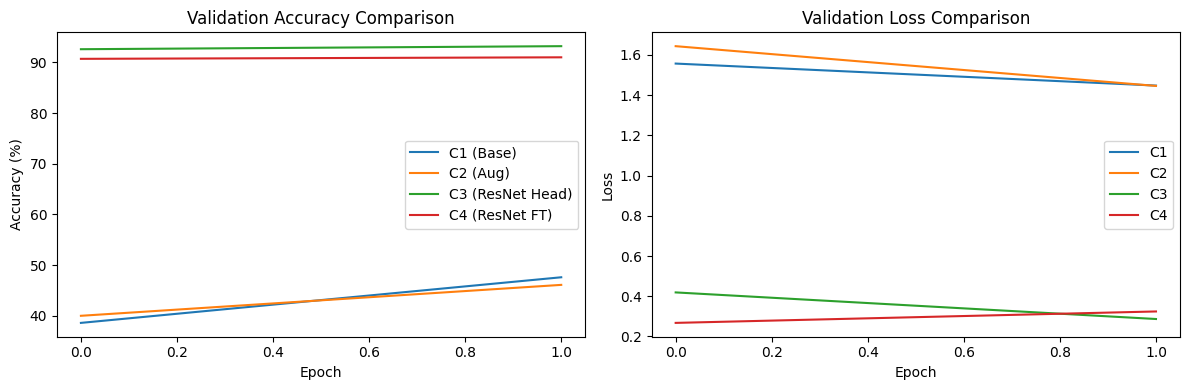

In [ ]:
# Финальный выбор и оценка на тесте
all_results = results # Из классификации
best_c_config = max(all_results, key=lambda x: x['val_acc'])
print(f"Лучший конфиг классификации: {best_c_config['config']} с Val Acc: {best_c_config['val_acc']:.2f}%")

# Загрузка лучшей модели для теста
model_test = None
if best_c_config['config'] == 'C1' or best_c_config['config'] == 'C2':
    model_test = SimpleCNN().to(device)
else:
    model_test = models.resnet18(pretrained=True)
    model_test.fc = nn.Linear(model_test.fc.in_features, 10)
    model_test = model_test.to(device)

model_test.load_state_dict(torch.load(f"artifacts/best_model_{best_c_config['config']}.pth"))
test_loss, test_acc = evaluate(model_test, test_loader, nn.CrossEntropyLoss(), device)
print(f"Финальная точность на тесте для {best_c_config['config']}: {test_acc:.2f}%")

# Визуализация историй обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_c1['val_acc'], label='C1 (Base)')
plt.plot(history_c2['val_acc'], label='C2 (Aug)')
plt.plot(history_c3['val_acc'], label='C3 (ResNet Head)')
plt.plot(history_c4['val_acc'], label='C4 (ResNet FT)')
plt.title('Сравнение валидационной точности')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_c1['val_loss'], label='C1')
plt.plot(history_c2['val_loss'], label='C2')
plt.plot(history_c3['val_loss'], label='C3')
plt.plot(history_c4['val_loss'], label='C4')
plt.title('Сравнение валидационного лосса')
plt.xlabel('Эпоха')
plt.ylabel('Лосс')
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/classification_comparison.png")
plt.show()

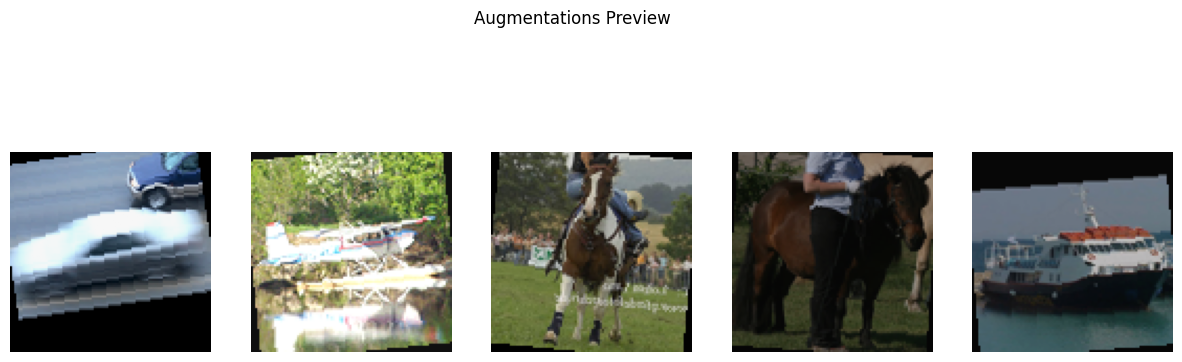

Final artifacts generated.


In [ ]:
import json

# Предпросмотр аугментаций
train_ds.transform = aug_transform
preview_loader = DataLoader(train_ds, batch_size=5, shuffle=True)
imgs, _ = next(iter(preview_loader))

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
    plt.axis('off')
plt.suptitle("Превью аугментаций")
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

# Конфиг лучшего классификатора
best_config_data = {
    "experiment_id": best_c_config['config'],
    "dataset": "STL10",
    "architecture": "ResNet18" if "ResNet" in best_c_config['desc'] else "SimpleCNN",
    "val_accuracy": best_c_config['val_acc'],
    "test_accuracy": test_acc,
    "seed": 42,
    "optimizer": "Adam",
    "lr": 0.001
}
with open("artifacts/best_classifier_config.json", "w", encoding='utf-8') as f:
    json.dump(best_config_data, f, indent=4, ensure_ascii=False)

# Итоговый runs.csv по требованиям
runs_df = pd.DataFrame([{
    "experiment_id": best_c_config['config'],
    "task": "classification",
    "dataset": "STL10",
    "best_val_accuracy": best_c_config['val_acc'],
    "test_accuracy": test_acc,
    "mean_iou": None
}, {
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "best_val_accuracy": None,
    "test_accuracy": None,
    "mean_iou": miou_v1
}])
runs_df.to_csv("artifacts/runs.csv", index=False)
print("Финальные артефакты созданы.")